<a href="https://colab.research.google.com/github/muneer-ahmad10/End_Module_exam_prep/blob/main/Weak_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Jupyter Notebook Execution Order**

In [ ]:
x=100

In [ ]:
print(x)

100


# **Broadcasting**

# **Tensor Memory**

In [ ]:
import torch

In [ ]:
x=torch.tensor([[1,2,3],[4,5,6]])

In [ ]:
y=x.view(3,2)

In [ ]:
y[0][0]=100

In [ ]:
y

tensor([[100,   2],
        [  3,   4],
        [  5,   6]])

In [ ]:
x

tensor([[100,   2,   3],
        [  4,   5,   6]])

In [ ]:
z=x.transpose(0,1)

In [ ]:
z

tensor([[100,   4],
        [  2,   5],
        [  3,   6]])

In [ ]:
x

tensor([[100,   2,   3],
        [  4,   5,   6]])

In [ ]:
x.view(3,2)

tensor([[100,   2],
        [  3,   4],
        [  5,   6]])

# **PyTorch Autograd + the Training Loop**

In [ ]:
x=torch.tensor(2.0,requires_grad=True)
x

tensor(2., requires_grad=True)

In [ ]:
y=x**2 + 3*x
y

tensor(10., grad_fn=<AddBackward0>)

In [ ]:
y.backward()

In [ ]:
y

tensor(10., grad_fn=<AddBackward0>)

In [ ]:
print(x.grad)

tensor(7.)


### **training loop in 5 Steps**



*   clear old grads
*   forward pass
*   compute loss
*   Backward pass
*   update weigts



In [ ]:
# for epoch in (num_epochs):
#   optimizer.zero_grad()
#   output=model(input)
#   loss=criterion(output,target)
#   loss.backward()
#   optimizer.step()

# **Questions and Answers**

1-You forget optimizer.zero_grad(). What concretely happens to your gradients over 2 iterations?

gradients accumulate by addition, not "recalculate wrong." After iteration 1, .grad holds the gradient from batch 1. In iteration 2, backward() adds batch 2's gradient on top of that — so .grad now equals batch1_grad + batch2_grad. The optimizer then updates weights using this inflated, incorrect sum instead of just batch 2's true gradient — which is why training becomes unstable or converges to the wrong place.

2-Why is loss.backward() called before optimizer.step(), and not the other way around?

optimizer.step() updates weights using whatever is currently stored in .grad. If you called step() before backward(), .grad would either be empty (None) or hold stale values from the previous iteration — so the optimizer would update weights using the wrong (or no) gradient information for the current batch. The order is mechanical, not about "getting loss minimum" directly — backward() is what computes the gradients that make minimization possible; step() just applies whatever gradient is sitting there at that moment.

3-x = torch.tensor(3.0, requires_grad=True); y = x**3. What is x.grad after y.backward()? (do the calculus)

y = x³ → dy/dx = 3x² → at x=3: 3 × 9 = 27

4-What would happen if you used nn.MSELoss for a classification problem with class labels 0,1,2 instead of nn.CrossEntropyLoss

MSE is for regression (continuous targets), CrossEntropy is for classification (discrete, unordered categories) — using the wrong one doesn't just work worse, it optimizes toward the wrong objective entirely.

# **Day 3 — Artificial Neural Networks (ANN)**

Perceptron → Multilayer Perceptron (MLP)
A single perceptron: output = activation(w·x + b) — a weighted sum of inputs, plus bias, passed through a nonlinear function. On its own, it can only learn linearly separable patterns (like a straight-line decision boundary).
An MLP stacks multiple layers of these. Each layer's output feeds into the next layer's input. This stacking + nonlinearity is what lets the network learn curved, complex decision boundaries instead of just straight lines.
Key insight for exams: if you remove the nonlinear activation functions, stacking layers becomes pointless — multiple linear layers collapse into a single linear layer mathematically (since a linear function of a linear function is still linear). Nonlinearity is why depth matters at all.

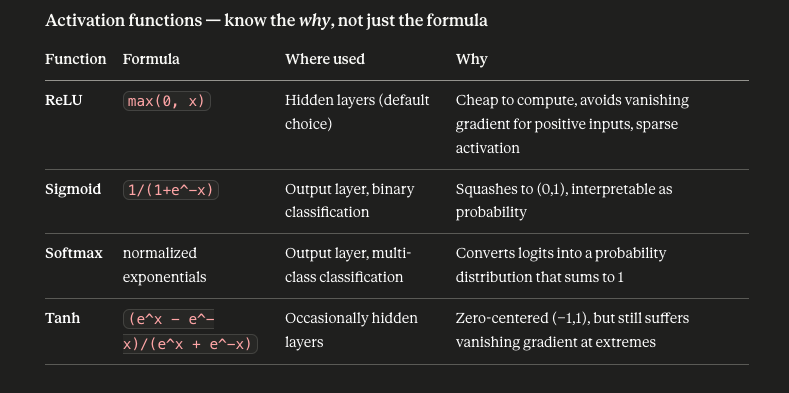


Why not sigmoid in every hidden layer (classic exam question): sigmoid's derivative is tiny when the input is very large or very small (the curve flattens at both ends). In a deep network, multiplying many small derivatives together during backprop causes the gradient to shrink toward zero as it propagates backward — the vanishing gradient problem. Early layers barely get updated, and training stalls. ReLU avoids this for positive inputs because its derivative is a constant 1.
Why softmax only on the output layer, never hidden layers: softmax forces outputs to sum to 1 and compete with each other (raising one score suppresses the others) — that's the exact behavior you want for "pick one class out of N" at the final layer, but it's actively harmful inside hidden layers where you want neurons to represent independent features, not a competing probability distribution.

In [ ]:
x = torch.arange(24).view(4,6)

In [ ]:
x

tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17],
        [18, 19, 20, 21, 22, 23]])

In [ ]:
x.view(3,8).shape[1]

8

Perceptron: One neuron → learns only linear boundaries.

MLP: Multiple layers + nonlinear activations → learns complex patterns.

ReLU: Best hidden-layer default (max(0, x)), helps avoid vanishing gradients for positive activations.

Sigmoid: Binary classification output (0–1 probability).

Softmax: Multi-class output, probabilities sum to 1.

No activation = multiple layers collapse into one linear layer.

Backpropagation: Error travels backward using the chain rule to update weights.

Dropout: Randomly turns off neurons only during training to reduce overfitting.

Weight Decay (L2): Penalizes large weights to improve generalization.

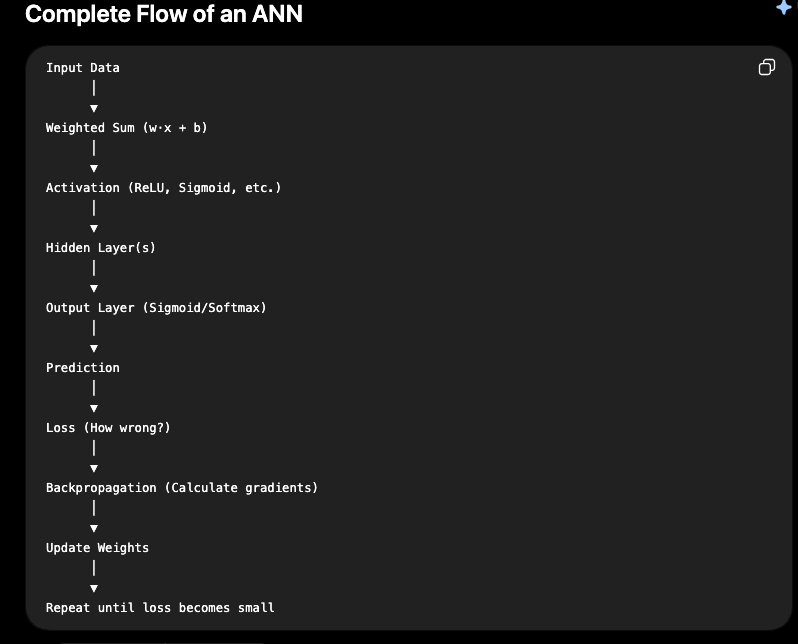

# **Backpropagation — the intuition (not full derivation)**

Backprop is just the chain rule, applied layer by layer, backward through the network.

Think of it as: "how much did this weight contribute to the final error, and in which direction should I nudge it to reduce that error?"

Forward pass: compute prediction, then loss (how wrong you were)
Backward pass: starting from the loss, work backward layer by layer, using the chain rule to figure out each weight's share of responsibility for the error (∂loss/∂weight)
Each weight gets nudged opposite to its gradient, scaled by the learning rate

You don't need to memorize the full derivative chain — but you should be able to explain why it's called "back"-propagation (error signal flows backward, opposite to the forward pass direction).

# **Overfitting — dropout & weight decay**

Overfitting: the model memorizes training data (including its noise) instead of learning generalizable patterns — great training accuracy, poor validation/test accuracy.

Dropout: during training, randomly "switches off" a fraction of neurons (e.g. 20-50%) on each forward pass. This forces the network to not rely too heavily on any single neuron/path, making it learn more robust, redundant representations. Dropout is only active during training — turned off during evaluation (model.eval() disables it).
Weight decay (L2 regularization): adds a penalty term to the loss proportional to the size of the weights, discouraging any single weight from growing very large. Large weights tend to make a model overly sensitive to small input changes — overfitting.

# **Convolutional Neural Networks (CNNs)**

**Why CNNs instead of plain ANN for images**

A fully-connected ANN treats every pixel as an independent input — for a 224×224 color image that's 150,528 inputs into just the first layer, with no sense that nearby pixels are related. CNNs fix this with two ideas:

Parameter sharing: the same small filter (kernel) slides across the whole image, so you learn one set of weights that detects a pattern (like an edge) anywhere in the image, not a separate weight for every pixel position.
Spatial locality: each output value only looks at a small local neighborhood of the input, matching how real visual patterns (edges, textures) are local, not global.

### **The convolution operation**

A small filter (e.g. 3×3) slides across the input, and at each position computes a weighted sum (dot product) between the filter and the patch of input it's covering. This produces a feature map.

**Key terms:**

**Kernel/filter size** — the dimensions of the sliding window (e.g. 3×3, 5×5)

**Stride**— how many pixels the filter moves each step (stride 1 = moves one pixel at a time; stride 2 = skips every other position, shrinking the output faster)

**Padding** — adding extra border pixels (usually zeros) around the input so the filter can also center on edge pixels, and to control output size

**Output Size Formulae**

output = floor( (input - kernel + 2×padding) / stride ) + 1

# **Pooling layers**

**Max pooling** takes the maximum value in each window (e.g. 2×2), **average pooling** takes the mean.

**Pooling:**

Reduces spatial dimensions (height/width) → less computation downstream
Reduces parameter count in later layers
Adds a degree of translation invariance (small shifts in the input don't change the pooled output much)
Does not have learnable weights — it's a fixed operation, not a trained layer

**Note:** pooling does not directly prevent overfitting by design (that's more dropout/weight decay's job) — but by reducing dimensionality it can indirectly help.

# **The Master CNN Architecture Walkthrough**

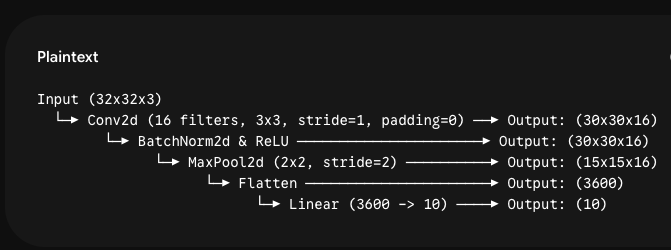

## **Stage-by-Stage**

**Stage 1:** Conv2d LayerConfiguration: 16 filters, kernel size $K = 3$, stride $S = 1$, padding $P = 0$.Input Shape: $32 \times 32 \times 3$Dimension Calculation:$$O = \left\lfloor \frac{32 - 3 + 2(0)}{1} \right\rfloor + 1 = 30$$Output Tensor Shape: $(30 \times 30 \times 16)$ (16 comes from the number of output filters)Parameter Calculation (CRUCIAL FOR NATs):$$\text{Params} = (\text{kernel\_h} \times \text{kernel\_w} \times \text{in\_channels} + 1_{\text{bias}}) \times \text{out\_channels}$$$$\text{Params} = (3 \times 3 \times 3 + 1) \times 16 = (27 + 1) \times 16 = 28 \times 16 = \mathbf{448 \text{ parameters}}$$

**Stage 2:** Activation & Normalization (BatchNorm + ReLU)BatchNorm2d(16): Normalizes activations across the batch.Shape: Unchanged $\rightarrow$ $(30 \times 30 \times 16)$Parameters: $2 \times \text{num\_features}$ (learnable scale $\gamma$ and shift $\beta$) $\rightarrow 2 \times 16 = \mathbf{32 \text{ parameters}}$.ReLU: Element-wise non-linearity ($\max(0, x)$).Shape: Unchanged $\rightarrow$ $(30 \times 30 \times 16)$Parameters: $0$ (activation functions have no learnable parameters).

**Stage 3:** MaxPool2d LayerConfiguration: Kernel size $K = 2$, Stride $S = 2$, Padding $P = 0$.Input Shape: $30 \times 30 \times 16$Dimension Calculation:$$O = \left\lfloor \frac{30 - 2 + 0}{2} \right\rfloor + 1 = \left\lfloor \frac{28}{2} \right\rfloor + 1 = 15$$Output Tensor Shape: $(15 \times 15 \times 16)$Parameters: $0$ (pooling simply extracts the maximum value in each $2 \times 2$ window; it has no weights).

**Stage 4:** Flatten LayerInput Shape: $15 \times 15 \times 16$Action: Collapses all multi-dimensional spatial features into a 1D vector.Calculation: $15 \times 15 \times 16 = 3,600$Output Vector Shape: $(3600,)$Parameters: $0$

**Stage 5:** Fully Connected (Linear) LayerConfiguration: nn.Linear(in_features=3600, out_features=10)Input Shape: $3600$Output Vector Shape: $(10,)$ (raw class logits)Parameter Calculation:$$\text{Params} = (\text{in\_features} \times \text{out\_features}) + \text{biases}$$$$\text{Params} = (3600 \times 10) + 10 = 36,000 + 10 = \mathbf{36,010 \text{ parameters}}$$

# **Practice**

Suppose you have a tensor of shape $(16 \times 16 \times 32)$ passing into a nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1).What is the output shape after this convolution? (Hint: Notice $K=3, P=1, S=1$)How many learnable parameters does this specific Conv2d layer have?

Question 1: What is the output shape?Your answer: 16, 16, 32Correct answer: 16 × 16 × 64Here is why:Spatial dimensions ($H \times W$): You got the $16 \times 16$ spatial shape 100% right!$$O = \left\lfloor \frac{16 - 3 + 2(1)}{1} \right\rfloor + 1 = \left\lfloor \frac{15}{1} \right\rfloor + 1 = 16$$Channel dimension ($C$): The output channel count is always determined by out_channels. Because the layer was set to out_channels=64, the depth changes from 32 to 64.Question 2: How many learnable parameters?Your answer: 354Correct answer: 18,496Let's plug the numbers into the parameter formula:$$\text{Params} = \Big( (\text{kernel\_h} \times \text{kernel\_w} \times \text{in\_channels}) + 1_{\text{bias}} \Big) \times \text{out\_channels}$$Size of ONE filter (with bias):$$(3 \times 3 \times 32) + 1 = (9 \times 32) + 1 = 288 + 1 = \mathbf{289 \text{ weights per filter}}$$Multiply by total number of filters (out_channels = 64):$$289 \times 64 = \mathbf{18,496 \text{ total parameters}}$$

### **Two Golden Exam Rules to Remember:**
Channel Rule:
Output depth is always equal to out_channels—the input channels don't survive the convolution; they get summed together!Parameter Rule: Each filter looks at ALL input channels. So don't forget to multiply $K \times K$ by in_channels before adding the bias and multiplying by out_channels.

# **CNN Mini Project: Full Architecture Reconstruction**

### **A typical CNN mini-project architecture (the kind you should be able to rebuild from memory)**

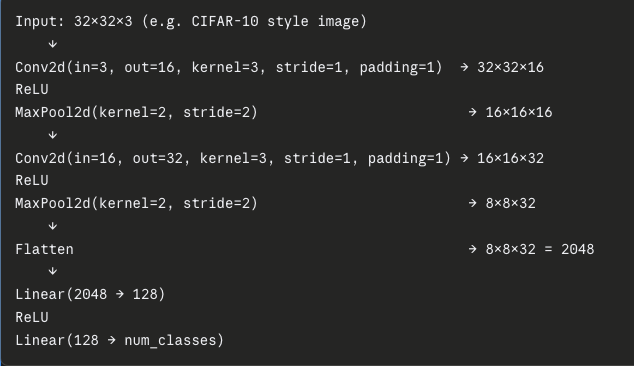

### **How to trace through this yourself**

**Conv layers** — use the formula: output = floor((input - kernel + 2×padding)/stride) + 1. With kernel=3, padding=1, stride=1 , spatial size never changes — only the channel count changes (to whatever out_channels you specified).

**Pool layers** — same formula, but no padding usually, and stride typically equals kernel size. MaxPool2d(kernel=2, stride=2) always halves height and width, channel count stays the same (pooling doesn't touch channels).

**Flatten** — multiply the final height × width × channels together into one number — that's your input size to the first Linear layer. This is the single most common place people get NAT questions wrong: forgetting to multiply all three dimensions.

**Linear layers** — straightforward matrix shape matching, in_features must equal whatever came out of the previous layer.

### **Why the architecture is shaped this way**

**Channels increase, spatial size decreases as you go deeper** — early layers use few filters (16) to detect simple features (edges) across a large spatial area; deeper layers use more filters (32) to detect more complex combinations across a now-smaller, more abstract representation.

**Pooling between conv blocks** — controls the explosion of parameters/computation, and forces the network to be robust to small translations.

**Flatten right before the Linear layers**— Conv/Pool layers preserve spatial structure (they operate on 2D grids), but Linear layers expect a flat 1D vector — this is the bridge between "spatial feature extraction" and "classification decision."

### **Given this pipeline, compute the shape after each step:**

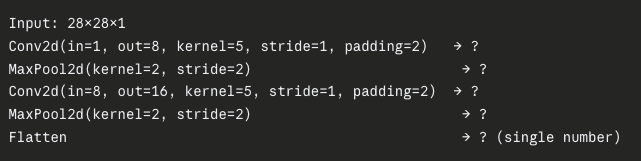

Step 1 — Conv2d(in=1, out=8, kernel=5, stride=1, padding=2):
(28 - 5 + 2×2)/1 + 1 = (28-5+4)/1 + 1 = 27+1 = 28
Output: 28×28×8. You wrote "23,28,8" — likely a typo, since your formula clearly worked out (kernel=5, padding=2 is the "same padding" pattern for 5×5 kernels, same idea as kernel=3/padding=1 — output size matches input). This one's just a typo, not a real error — good work getting the actual same-padding logic right implicitly.

Step 2 — MaxPool2d(kernel=2, stride=2): ✅ Correct. 28/2 = 14 → 14×14×8.

Step 3 — Conv2d(in=8, out=16, kernel=5, stride=1, padding=2): ✅ Correct. Same-padding again, spatial size unchanged → 14×14×16.

Step 4 — MaxPool2d(kernel=2, stride=2): ✅ Correct. 14/2 = 7 → 7×7×16.

Step 5 — Flatten: ❌ Not quite. You need to multiply all three dimensions together: 7 × 7 × 16 = 784...

wait — let's actually compute it: 7×7 = 49, 49×16 = 784. That's actually correct! Let me double check: yes, 49 × 16 = 784 exactly.

# **RNNs, LSTMs & the Bridge to Transformers**

### **Why RNNs exist — the problem with plain ANNs/CNNs for sequences**

ANNs and CNNs assume each input is independent (or spatially local). But text, speech, and time-series data have order and dependency — "the cat sat" isn't the same as "sat cat the." You need a model that remembers what came before while processing what comes next.

## **The RNN mechanism**

An RNN processes a sequence one step at a time, maintaining a hidden state that carries information forward:

h_t = activation(W_h · h_{t-1} + W_x · x_t + b)